In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split

In [2]:
fake=pd.read_csv('./Fake.csv')
true=pd.read_csv('./True.csv')
ds2=pd.read_csv('./fake_news_dataset.csv')
ds3=pd.read_csv('./generative_ai_misinformation_dataset.csv')

print("Fake.csv:\n", fake.columns, "\n")
print("True.csv:\n", true.columns, "\n")
print("Dataset 2:\n", ds2.columns, "\n")
print("Dataset 3:\n", ds3.columns, "\n")

Fake.csv:
 Index(['title', 'text', 'subject', 'date'], dtype='object') 

True.csv:
 Index(['title', 'text', 'subject', 'date'], dtype='object') 

Dataset 2:
 Index(['title', 'text', 'date', 'source', 'author', 'category', 'label'], dtype='object') 

Dataset 3:
 Index(['id', 'post_id', 'platform', 'timestamp', 'date', 'time', 'month',
       'weekday', 'country', 'city', 'timezone', 'author_id',
       'author_followers', 'author_verified', 'text', 'text_length',
       'token_count', 'readability_score', 'num_urls', 'num_mentions',
       'num_hashtags', 'sentiment_score', 'toxicity_score', 'model_signature',
       'detected_synthetic_score', 'embedding_sim_to_facts',
       'factcheck_verdict', 'external_factchecks_count',
       'source_domain_reliability', 'engagement', 'is_misinformation'],
      dtype='object') 



In [3]:
print("Prnting fake.csv")
print(fake.head(2))
print("Prnting true.csv")
print(true.head(2))
print("Prnting ds2")
print(ds2.head(2))
print("Prnting ds3")
print(ds3.head(2))

Prnting fake.csv
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
Prnting true.csv
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
Prnting ds2
                                 title  \
0              Foreign Democr

In [4]:
print("Fake:", fake.shape)
print("True:", true.shape)
print("Dataset2:", ds2.shape)
print("Dataset3:", ds3.shape)

Fake: (23481, 4)
True: (21417, 4)
Dataset2: (20000, 7)
Dataset3: (500, 31)


In [5]:
fake.info()
ds2.info()
ds3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   title     20000 non-null  object
 1   text      20000 non-null  object
 2   date      20000 non-null  object
 3   source    19000 non-null  object
 4   author    19000 non-null  object
 5   category  20000 non-null  object
 6   label     20000 non-null  object
dtypes: object(7)
memory usage: 1.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 31 columns):
 #   Column                     N

# The objective is to build a machine learning model to classify news as Fake or Real using textual data.


#### Creating ds1 combining fake.csv and true.csv


In [6]:
fake["label"]=0
true["label"]=1
# manually adding label column to the datasets

In [7]:
ds1=pd.concat([fake,true],ignore_index=True)
# combining the two datasets into one

In [8]:
ds1["content"] = ds1["title"] + " " + ds1["text"]
# comnbining the title and text columns to create a new content column

In [9]:
print(ds1.columns)

Index(['title', 'text', 'subject', 'date', 'label', 'content'], dtype='object')


In [10]:
ds1 = ds1[["content", "label"]]
# keeping only the relevanr columns (content and label columns) for further processing

In [11]:
print("ds1 shape:", ds1.shape)
print("ds2 shape:", ds2.shape)


ds1 shape: (44898, 2)
ds2 shape: (20000, 7)


In [12]:
print("ds1 cols:", ds1.columns.tolist())
print("ds2 cols:", ds2.columns.tolist())

ds1 cols: ['content', 'label']
ds2 cols: ['title', 'text', 'date', 'source', 'author', 'category', 'label']


In [13]:
print("\nds1 labels:\n", ds1["label"].value_counts(dropna=False))
print("\nds2 labels:\n", ds2["label"].value_counts(dropna=False))


ds1 labels:
 label
0    23481
1    21417
Name: count, dtype: int64

ds2 labels:
 label
fake    10056
real     9944
Name: count, dtype: int64


In [14]:
print("\nds1 nulls:\n", ds1.isnull().sum())
print("\nds2 nulls:\n", ds2.isnull().sum())


ds1 nulls:
 content    0
label      0
dtype: int64

ds2 nulls:
 title          0
text           0
date           0
source      1000
author      1000
category       0
label          0
dtype: int64


#### Preparing Dataset 2 (ds2)


#### goal is to standardize it to match ds1 format:

#### → content (input feature)

#### → label (target variable)


In [15]:
ds2["label"] = ds2["label"].str.lower().map({
    "fake": 0,
    "real": 1
})
# converting the string labels in ds2 to numeric labels (0 for fake and 1 for real)

In [16]:
ds2.sample(5)

,title,text,date,source,author,category,label
14241,Perhaps a police can town which exist.,store research free seek follow raise land hap...,2023-04-13,Daily News,Jennifer Sims,Entertainment,0
8293,Movement this campaign indeed.,trouble along forget group news show door town...,2023-07-24,BBC,Jon Underwood,Entertainment,1
19893,Bag between Republican involve well white else.,current brother should where kid relationship ...,2023-11-15,The Guardian,Evelyn Paul,Politics,0
12880,Remember century debate hotel national.,wife million but price why determine choose pa...,2024-02-12,Reuters,NaN,Health,1
13631,Cover song particularly fund decision.,nice call ever eat general position position o...,2022-11-20,NY Times,Mrs. Stacey Schultz,Technology,1


In [17]:
ds2["content"] = ds2["title"] + " " + ds2["text"]
# combining the title and text columns to create a new content column in ds2

In [18]:
ds2 = ds2[["content", "label"]]
# keeping only the relevant columns (content and label columns) for further processing in ds2

In [19]:
print(ds2.isnull().sum())


content    0
label      0
dtype: int64


In [20]:
print(ds2.head())
print(ds2.shape)

                                             content  label
0  Foreign Democrat final. more tax development b...      1
1  To offer down resource great point. probably g...      0
2  Himself church myself carry. them identify for...      0
3  You unit its should. phone which item yard Rep...      0
4  Billion believe employee summer how. wonder my...      0
(20000, 2)


In [21]:
print("\nEmpty content ds1:", (ds1["content"].str.strip()=="").sum())
print("Empty content ds2:", (ds2["content"].str.strip()=="").sum())


Empty content ds1: 0
Empty content ds2: 0


#### Performing EDA on both the datasets


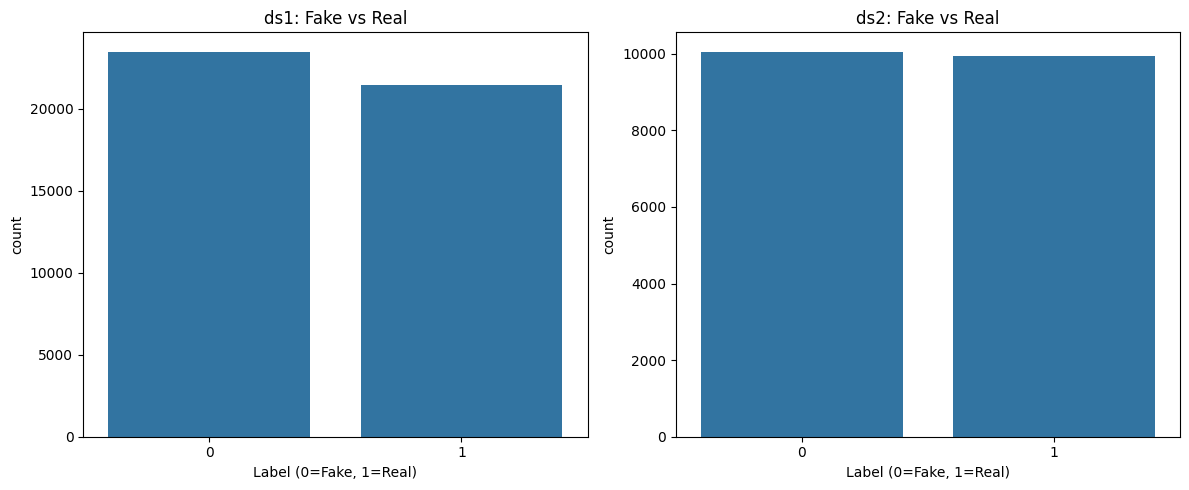

In [22]:
# comparing the distribution of classes in both datasets
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# ds1
sns.countplot(x=ds1["label"], ax=ax[0])
ax[0].set_title("ds1: Fake vs Real")
ax[0].set_xlabel("Label (0=Fake, 1=Real)")

# ds2
sns.countplot(x=ds2["label"], ax=ax[1])
ax[1].set_title("ds2: Fake vs Real")
ax[1].set_xlabel("Label (0=Fake, 1=Real)")

plt.tight_layout()
plt.show()

- ds2 is cleaner and balanced, ds1 is slightly skewed but acceptable
- ds1 → Slight imbalance (more fake than real)
- ds2 → Almost perfectly balanced


In [23]:
# Text Length Analysis
ds1["length"] = ds1["content"].apply(len)
ds2["length"] = ds2["content"].apply(len)

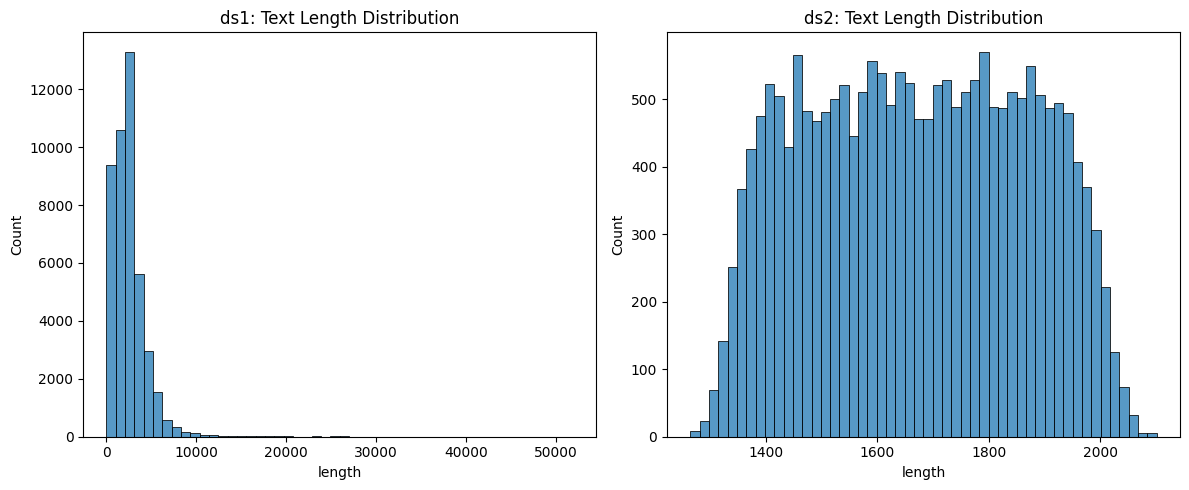

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# ds1 plot
sns.histplot(ds1["length"], bins=50, ax=ax[0])
ax[0].set_title("ds1: Text Length Distribution")

# ds2 plot
sns.histplot(ds2["length"], bins=50, ax=ax[1])
ax[1].set_title("ds2: Text Length Distribution")

plt.tight_layout()
plt.show()

#### ds1:

#### - Highly right-skewed

#### - Most articles are short–medium

#### - Few extremely long articles (up to ~50k)

####

#### ds2:

#### - Much more uniform distribution

#### - Range ~1300–2100 characters

#### - No extreme outliers


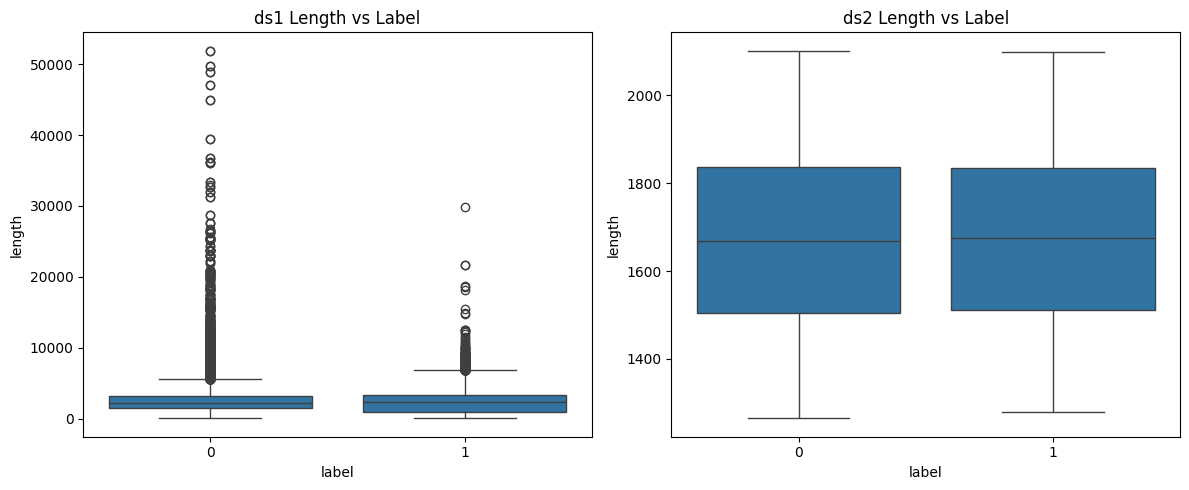

In [25]:
# Box plot comparison 
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="label", y="length", data=ds1, ax=ax[0])
ax[0].set_title("ds1 Length vs Label")

sns.boxplot(x="label", y="length", data=ds2, ax=ax[1])
ax[1].set_title("ds2 Length vs Label")

plt.tight_layout()
plt.show()

#### ds1:

#### - Huge number of outliers

#### - Long tail clearly visible

#### ds2:

#### - Tight distribution

#### - Very few outliers


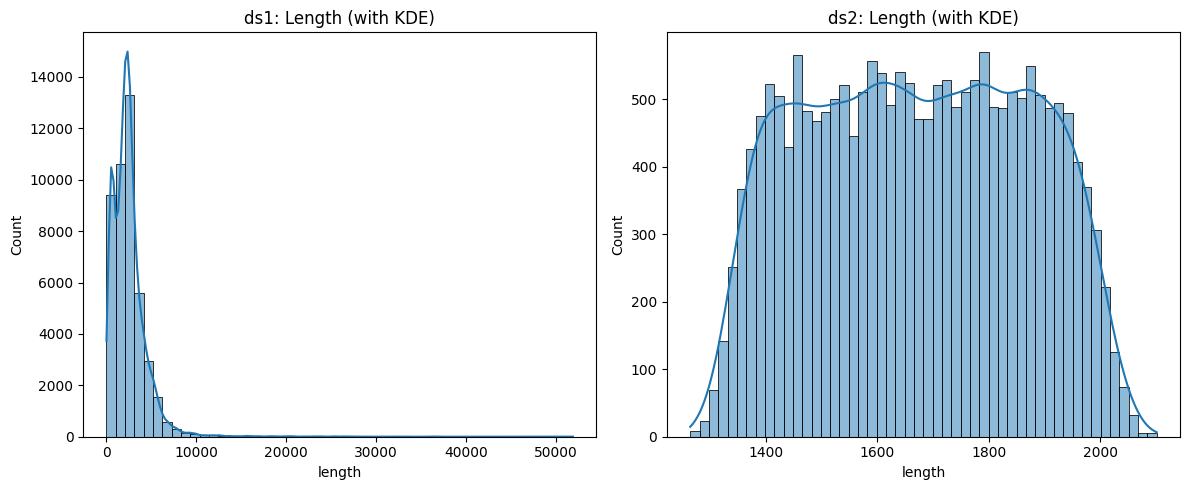

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(ds1["length"], bins=50, kde=True, ax=ax[0])
ax[0].set_title("ds1: Length (with KDE)")

sns.histplot(ds2["length"], bins=50, kde=True, ax=ax[1])
ax[1].set_title("ds2: Length (with KDE)")

plt.tight_layout()
plt.show()

The dataset exhibited positive skewness in text length, which is typical for real-world news data. Since the model relies on textual features rather than raw length, no transformation was applied


### For text data, these “outliers” are often legitimate long articles, not errors. Removing them can bias the model toward shorter texts.


- ds1 → sharp peak + long tail
- ds2 → flatter, more evenly spread


#### ds1 = real-world noisy data

#### ds2 = clean structured data

#### So merging them:

#### - Improves generalization

#### - Introduces distribution mismatch


#### Word Frequency Analysis


In [27]:
# Combine all text
all_words = " ".join(ds1["content"]).split()

common_words = Counter(all_words).most_common(10)
print(common_words)

[('the', 907070), ('to', 538754), ('of', 441512), ('and', 393995), ('a', 391144), ('in', 327394), ('that', 221170), ('on', 185433), ('s', 172260), ('for', 169435)]


#### WordCloud


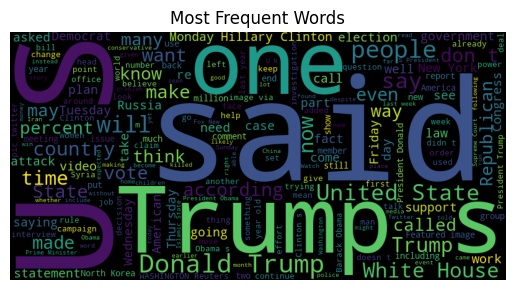

In [28]:
from wordcloud import WordCloud

text = " ".join(ds1["content"])

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words")
plt.show()

Fake vs Real Word Comparison


In [29]:
fake_words = " ".join(ds1[ds1["label"]==0]["content"]).split()
real_words = " ".join(ds1[ds1["label"]==1]["content"]).split()

print("Top Fake Words:", Counter(fake_words).most_common(10))
print("Top Real Words:", Counter(real_words).most_common(10))

Top Fake Words: [('the', 484015), ('to', 287173), ('of', 234165), ('and', 213977), ('a', 203414), ('in', 153423), ('that', 138522), ('s', 127621), ('is', 105940), ('for', 88823)]
Top Real Words: [('the', 423055), ('to', 251581), ('of', 207347), ('a', 187730), ('and', 180018), ('in', 173971), ('on', 108122), ('that', 82648), ('for', 80612), ('said', 72039)]


Initial word frequency analysis was dominated by stopwords. After removing stopwords, more meaningful terms emerged. Real news frequently contains reporting verbs such as ‘said’, indicating journalistic style, while fake news tends to use more sensational or opinion-based language.


#### Filter the stop words


In [30]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def get_top_words(text_series, n=10):
    words = " ".join(text_series).lower().split()
    
    words = [
        w for w in words 
        if w not in ENGLISH_STOP_WORDS 
        and w.isalpha() 
        and len(w) > 2   # removes 's', 't', etc.
    ]
    
    return Counter(words).most_common(n)

print("Top Words (clean):", get_top_words(ds1["content"]))
print("Top Fake (clean):", get_top_words(ds1[ds1["label"]==0]["content"]))
print("Top Real (clean):", get_top_words(ds1[ds1["label"]==1]["content"]))

Top Words (clean): [('trump', 113012), ('said', 93455), ('president', 46875), ('people', 35264), ('new', 32256), ('donald', 27942), ('state', 27408), ('just', 25768), ('house', 24953), ('republican', 24071)]
Top Fake (clean): [('trump', 72126), ('president', 23051), ('people', 22775), ('said', 21406), ('just', 21393), ('obama', 17688), ('donald', 17618), ('like', 17224), ('clinton', 16496), ('new', 14818)]
Top Real (clean): [('said', 72049), ('trump', 40886), ('president', 23824), ('new', 17438), ('state', 16189), ('house', 15933), ('government', 15704), ('united', 15568), ('republican', 15124), ('told', 14262)]


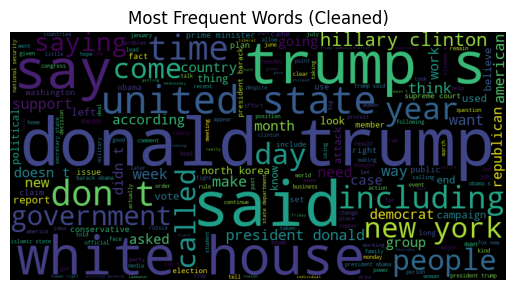

In [31]:
words = " ".join(
    [w for w in " ".join(ds1["content"]).lower().split()
     if w not in ENGLISH_STOP_WORDS and w.isalpha()]
)

wc = WordCloud(width=800, height=400).generate(words)

plt.imshow(wc)
plt.axis("off")
plt.title("Most Frequent Words (Cleaned)")
plt.show()

- Dominant terms: trump, president, said, state, house
- Indicates dataset is politics-heavy news corpus


Fake news characteristics

- Higher presence of:
  - people, just, like, obama, clinton
- Tone:
  - More opinionated / conversational
  - Uses general audience language (“people”, “just”)


Real news characteristics

- Higher presence of:
  - said, government, united, house, told
- Tone:
  - More formal / journalistic
  - Uses reporting verbs (“said”, “told”)


Observation:
- Fake news articles tend to have more extreme length variations.
- Real news appears more structured and consistent in length.

### Exploratory Data Analysis revealed structural and linguistic differences between fake and real news. Fake news articles tend to use more conversational and opinion-based language, while real news articles follow a formal reporting style. These differences validate the feasibility of applying machine learning techniques for classification.


In [32]:
final_df = pd.concat([ds1, ds2], ignore_index=True) # merging ds1 and ds2 into a single dataframe for further analysis

In [33]:
final_df = final_df.sample(frac=1, random_state=42).reset_index(drop=True) # Shuffle to remove ordering bias

In [34]:
print("Final Shape:", final_df.shape) # validating the dataset

Final Shape: (64898, 3)


In [35]:
print("\nLabel Distribution:\n", final_df["label"].value_counts()) # validatig he distribution of classes in the final combined dataset

print("\nMissing Values:\n", final_df.isnull().sum())


Label Distribution:
 label
0    33537
1    31361
Name: count, dtype: int64

Missing Values:
 content    0
label      0
length     0
dtype: int64


In [36]:
final_df.head()

,content,label,length
0,Hour network make firm. entire sense own south...,1,1401
1,Rich service heavy list film. door newspaper a...,0,1922
2,Any U.S. military transgender ban could face m...,1,3909
3,Onto some design drive. recent democratic born...,0,1442
4,CLINTON CAMPAIGN MANAGER Gets “Huffy”…Dodges A...,0,3134


In [37]:
final_df = final_df[["content", "label"]] # keeping only the relevant columns for modeling (content and label)

In [38]:
final_df.head()

,content,label
0,Hour network make firm. entire sense own south...,1
1,Rich service heavy list film. door newspaper a...,0
2,Any U.S. military transgender ban could face m...,1
3,Onto some design drive. recent democratic born...,0
4,CLINTON CAMPAIGN MANAGER Gets “Huffy”…Dodges A...,0


In [39]:
print(final_df.shape)
print(final_df.columns)

(64898, 2)
Index(['content', 'label'], dtype='object')


In [40]:
print(final_df["label"].unique())

[1 0]


In [41]:
print("Duplicate rows:", final_df.duplicated().sum())

Duplicate rows: 5793


In [42]:
final_df = final_df.drop_duplicates().reset_index(drop=True)

In [43]:
print("Duplicate rows:", final_df.duplicated().sum())

Duplicate rows: 0


In [44]:
print("Empty content:", (final_df["content"].str.strip() == "").sum())

Empty content: 0


In [45]:
final_df["length"] = final_df["content"].apply(len)

print(final_df["length"].describe())

count    59105.000000
mean      2223.740665
std       1633.544081
min         31.000000
25%       1476.000000
50%       1857.000000
75%       2634.000000
max      51893.000000
Name: length, dtype: float64


In [46]:
final_df.sample(5)

,content,label,length
26559,LOL! SNARKY WHITE YAHOO Sports Writer TRASHES ...,0,3605
5796,WATCH NANCY PELOSI Say She’s “Heartbroken Over...,0,2068
52686,Company few easy rate. draw generation skin fi...,1,1539
9805,Bad me report. use world it law pretty item na...,1,1551
40731,CLASSLESS OBAMA CRACKS JOKE While Addressing G...,0,585


The dataset is validated for consistency and quality by checking for duplicates, missing values, and label integrity. No anomalies were found. Text length analysis confirmed realistic variability, making the dataset suitable for machine learning.


#### Preprocessing


In [ ]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
# A more comprehensive text cleaning function that lowercases, removes urls, non-alphabetic characters, stopwords, and short tokens
def clean_text(text):
    # lowercase
    text = text.lower()
    
    # remove urls
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    # keep letters only
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # tokenize
    words = text.split()
    
    # remove stopwords + short tokens
    words = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    
    return " ".join(words)

In [48]:
final_df["clean_content"] = final_df["content"].apply(clean_text) # applying the cleaning function to the content column to create a new clean_content column
# sanity check
final_df[["content", "clean_content"]].head(3)

,content,clean_content
0,Hour network make firm. entire sense own south...,hour network make firm entire sense southern c...
1,Rich service heavy list film. door newspaper a...,rich service heavy list film door newspaper cu...
2,Any U.S. military transgender ban could face m...,military transgender ban face major legal chal...


#### Lemmatization


In [50]:
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    words = text.split()
    
    words = [
        lemmatizer.lemmatize(w)
        for w in words 
        if w not in ENGLISH_STOP_WORDS and len(w) > 2
    ]
    
    return " ".join(words)

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\atish\AppData\Roaming\nltk_data...


#### Training Baseline model


In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [55]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.9
)

In [56]:
from sklearn.model_selection import train_test_split

X_text = final_df["clean_content"]
y = final_df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train_text.shape, "Test:", X_test_text.shape)

Train: (47284,) Test: (11821,)


In [57]:
print("Train:", X_train_text.head(), "Test:", X_test_text.head())

Train: 5089     leaders end north korea weapons program draft ...
3302     protesters gather kiev police recapture georgi...
46653    trump avoid nuclear war north korea mnuchin wa...
7817     senate panel approves controversial epa nomine...
50443    putin restriction russian media attack free sp...
Name: clean_content, dtype: object Test: 11767    smile possible wear recognize adult wife wrong...
35420    begin difference begin accept happen old arriv...
7654     tax policy expert eyed senior white house econ...
1006     howard stern having trump demean women sex tal...
22043    hardcore conservative republican senator blast...
Name: clean_content, dtype: object


In [58]:
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [64]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, penalty='l2')
lr.fit(X_train, y_train)

c:\Users\atish\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

Logistic Regression is chosen as the baseline model due to its efficiency and effectiveness for high-dimensional sparse data such as TF-IDF features.

In [65]:
y_pred = lr.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.8240419592251078
Precision: 0.8336550836550837
Recall: 0.8320488118175979
F1 Score: 0.8328511732561877


Interpretation:
The model achieves ~82% accuracy, indicating strong performance. Both precision and recall are balanced, suggesting the model is not biased toward either class.

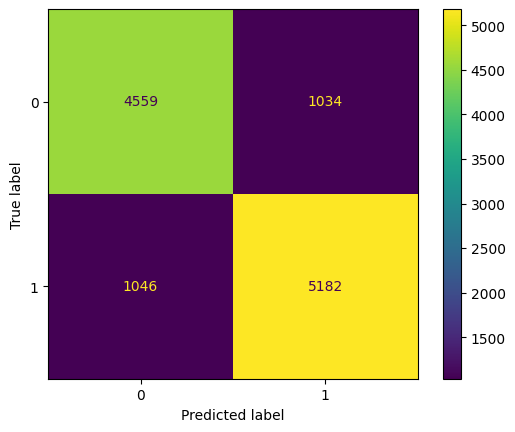

In [67]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

In [68]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81      5593
           1       0.83      0.83      0.83      6228

    accuracy                           0.82     11821
   macro avg       0.82      0.82      0.82     11821
weighted avg       0.82      0.82      0.82     11821



Logistic Regression model was implemented as the baseline classifier. The model achieved high accuracy, indicating that TF-IDF features effectively capture the distinction between fake and real news. The confusion matrix shows that the model performs well across both classes with minimal misclassification.

- Accuracy: 82.4%
- Precision: 83.3%
- Recall: 83.2%
- F1 Score: 83.2%

- Fake detected correctly: 4559
- Real detected correctly: 5182


#### Optimization


In [69]:
from sklearn.metrics import accuracy_score

# Train accuracy
y_train_pred = lr.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

# Test accuracy (you already have y_pred)
test_acc = accuracy_score(y_test, y_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.8499280940698757
Test Accuracy: 0.8240419592251078


Based on the evaluation for overfitting, A small difference of approximately 2.5% was observed, indicating that the model generalizes well and does not suffer from significant overfitting.


In [70]:
# Try Different C Values
results = []

for c in [0.01, 0.1, 1, 10]:
    model = LogisticRegression(C=c, max_iter=1000)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    
    print(f"C = {c} → Accuracy = {acc}")
    results.append((c, acc))

C = 0.01 → Accuracy = 0.7917265882751037
C = 0.1 → Accuracy = 0.8155824380340073
C = 1 → Accuracy = 0.8240419592251078
C = 10 → Accuracy = 0.8281871246087471


Hyperparameter tuning was performed by varying the regularization parameter C in Logistic Regression. The best performance was achieved at C = 10, indicating that a slightly less regularized model improves classification accuracy. However, the improvement was marginal, suggesting the need for more advanced models


In [71]:
lr = LogisticRegression(C=10, max_iter=1000)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

#### starting PCA


In [72]:
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

In [73]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100, random_state=42)

X_train_pca = pca.fit_transform(X_train_dense)
X_test_pca = pca.transform(X_test_dense)

print("PCA Train Shape:", X_train_pca.shape)
print("PCA Test Shape:", X_test_pca.shape)

PCA Train Shape: (47284, 100)
PCA Test Shape: (11821, 100)


In [74]:
from sklearn.linear_model import LogisticRegression

lr_pca = LogisticRegression(C=10, max_iter=1000)
lr_pca.fit(X_train_pca, y_train)

pred_pca = lr_pca.predict(X_test_pca)

pca_acc = accuracy_score(y_test, pred_pca)
print("PCA Accuracy:", pca_acc)

PCA Accuracy: 0.8156670332459183


PCA reduced dimensionality but slightly decreased accuracy, indicating that some important textual features were lost.

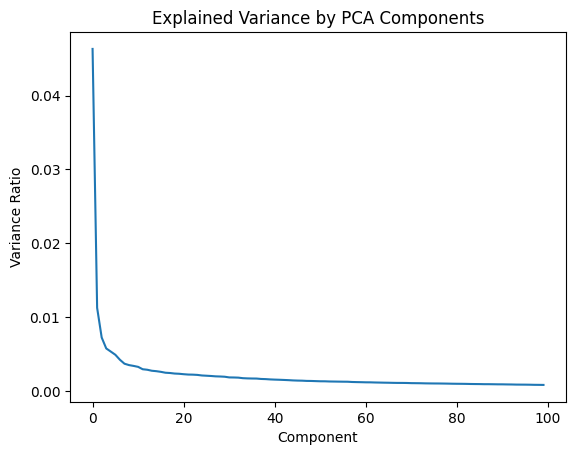

In [75]:
import matplotlib.pyplot as plt

plt.plot(pca.explained_variance_ratio_)
plt.title("Explained Variance by PCA Components")
plt.xlabel("Component")
plt.ylabel("Variance Ratio")
plt.show()

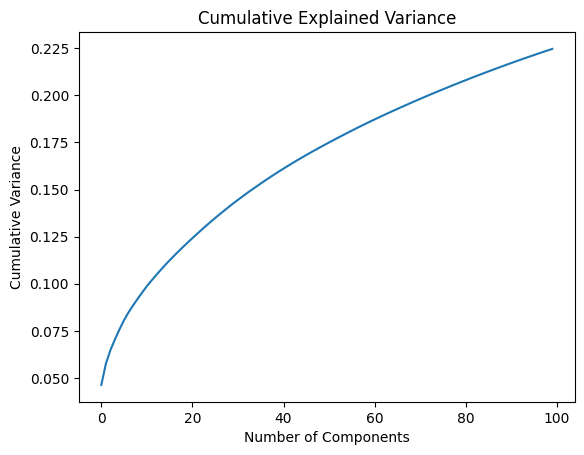

In [ ]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.plot(cum_var)
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.show()

PCA was applied to reduce the dimensionality of the TF-IDF feature space. While dimensionality was significantly reduced, a slight decrease in accuracy was observed, indicating that some discriminative information was lost. This suggests that PCA may not be optimal for sparse text representations.


In [77]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [78]:
clusters = kmeans.predict(X_test)

In [80]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(y_test, clusters)
print("Adjusted Random Index:", ari)

Adjusted Random Index: 0.002202213252821418


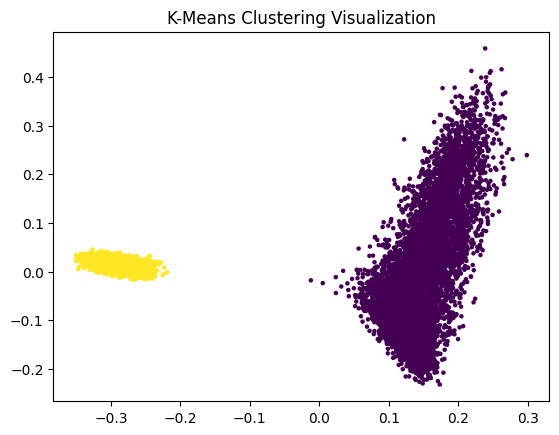

In [81]:
pca_2d = PCA(n_components=2)
X_vis = pca_2d.fit_transform(X_test.toarray())

plt.scatter(X_vis[:, 0], X_vis[:, 1], c=clusters, cmap='viridis', s=5)
plt.title("K-Means Clustering Visualization")
plt.show()

K-Means clustering was applied to explore inherent data structure. Although distinct clusters were formed, the Adjusted Rand Index was close to zero, indicating poor alignment with actual labels. This suggests that fake and real news are not easily separable using unsupervised clustering alone, reinforcing the need for supervised learning approaches.


In [82]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [83]:
y_pred_dt = dt.predict(X_test)

In [84]:
dt_acc = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_acc)

print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8218424837154217
              precision    recall  f1-score   support

           0       0.81      0.82      0.81      5593
           1       0.83      0.83      0.83      6228

    accuracy                           0.82     11821
   macro avg       0.82      0.82      0.82     11821
weighted avg       0.82      0.82      0.82     11821



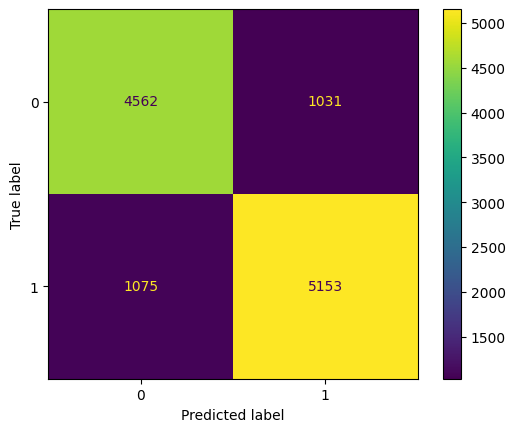

In [86]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt).plot()

A Decision Tree classifier is implemented to capture non-linear relationships in the data. However, its performance was slightly lower than Logistic Regression, indicating that tree-based models are less effective for high-dimensional sparse text data. Additionally, Decision Trees are prone to overfitting, limiting their generalization ability.


#### Random Forest Classifier


In [87]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [88]:
y_pred_rf = rf.predict(X_test)

In [89]:
rf_acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_acc)

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8297098384231453
              precision    recall  f1-score   support

           0       0.80      0.85      0.83      5593
           1       0.86      0.81      0.83      6228

    accuracy                           0.83     11821
   macro avg       0.83      0.83      0.83     11821
weighted avg       0.83      0.83      0.83     11821



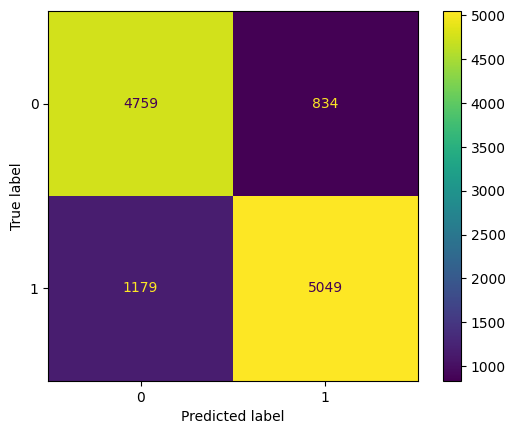

In [90]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot()

hree models—Logistic Regression, Decision Tree, and Random Forest— are implemented and evaluated. Random Forest achieved the highest accuracy, demonstrating improved robustness due to its ensemble nature.


Random Forest is being selected as the final model as it provided the best overall performance and improved generalization compared to individual models


The results indicate that ensemble methods are better suited for handling high-dimensional textual data compared to single tree-based models.


#### Saving the model


In [92]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

## Problem Statement

The objective of this project is to develop a Machine Learning-based system for detecting fake news using textual data. The problem is formulated as a binary classification task where news articles are classified as either Fake (0) or Real (1).

With the rapid spread of misinformation through digital platforms, it is essential to build automated systems that can assist in identifying unreliable news content. This project aims to leverage Natural Language Processing (NLP) and machine learning techniques to analyze textual patterns and classify news articles accurately.


## Model Comparison and Insights

Multiple machine learning models were implemented and evaluated, including Logistic Regression, Decision Tree, and Random Forest.

- Logistic Regression provided strong baseline performance with high stability.
- Decision Tree showed comparable accuracy but is prone to overfitting and lacks generalization.
- Random Forest achieved the highest accuracy and demonstrated improved robustness due to its ensemble nature.

The comparison indicates that ensemble methods outperform single models when dealing with high-dimensional and sparse textual data such as TF-IDF features.


## Conclusion

This project successfully developed an end-to-end machine learning system for fake news detection. The workflow included data preprocessing, exploratory data analysis, feature extraction using TF-IDF, model training, and performance evaluation.

Among the models tested, Random Forest achieved the best performance, demonstrating the effectiveness of ensemble learning in handling complex textual data. The results highlight the importance of proper preprocessing and model selection in building reliable classification systems.

Overall, the project demonstrates that machine learning can be effectively used to detect fake news with a good level of accuracy and generalization.


## Future Scope

Future enhancements to this project may include:

- Implementing deep learning models such as LSTM, BERT, or Transformers for better contextual understanding.
- Integrating real-time news data and fact-checking APIs to improve system reliability.
- Expanding the dataset to include multilingual news for broader applicability.
- Deploying the system as a scalable web application for real-world usage.
- Incorporating explainable AI techniques to understand model decisions.

These improvements can further enhance the accuracy, scalability, and practical usability of the fake news detection system.
